# Notebook: Redes Neuronales Convolucionales (CNN) para Imágenes Médicas

Este notebook es una guía completa y práctica para aprender **CNN (Convolutional Neural Networks)** aplicadas a **imágenes médicas**.

Trabajaremos con un conjunto de datos **libre y de fácil descarga** desde el paquete `medmnist`: **PneumoniaMNIST**, un dataset de radiografías de tórax en formato 2D, con etiquetas binarias (neumonía vs. no neumonía).

Al final tendrás:
- Un modelo CNN entrenado desde cero.
- Un ejemplo de **transfer learning** usando un modelo preentrenado.
- Evaluación con métricas útiles en contexto médico.
- Un vistazo a interpretabilidad con **Grad-CAM**.

⚠️ Nota importante (contexto médico): este material es educativo. Un modelo entrenado aquí **no** debe usarse para diagnóstico clínico sin validación rigurosa, controles de sesgo, y aprobación regulatoria.


## 1. ¿Qué es una CNN y por qué se usa en imágenes?

Una **CNN** es un tipo de red neuronal diseñada para trabajar con datos que tienen estructura espacial, como imágenes.

En una imagen, los píxeles cercanos suelen estar relacionados (bordes, texturas, formas). Las CNN explotan esta propiedad mediante **convoluciones**, que son filtros aprendibles que se deslizan por la imagen para detectar patrones.

### 1.1. Componentes clave

**(a) Convolución (Conv2D)**
- Aplica filtros (kernels) para obtener mapas de características.
- Aprende detectores de bordes, texturas y estructuras más complejas en capas profundas.

**(b) Activación (ReLU)**
- Introduce no linealidad.
- ReLU(x) = max(0, x) suele funcionar muy bien.

**(c) Pooling (MaxPool)**
- Reduce resolución espacial, mantiene información importante.
- Ayuda a generalización y reduce costo computacional.

**(d) Capas fully-connected (densas)**
- Integran la información para clasificación/regresión.

### 1.2. ¿Por qué CNN para imágenes médicas?
- Detectan patrones sutiles (opacidades, consolidaciones, cambios de textura).
- Pueden aprender representaciones jerárquicas sin ingeniería manual de características.
- Con **transfer learning**, aprovechan conocimiento de grandes datasets para mejorar rendimiento con menos datos.


## 2. Preparación del entorno

Usaremos **PyTorch** para construir y entrenar modelos. También usaremos `medmnist` para descargar el dataset.

Si estás en un entorno local, ejecuta la instalación. En entornos tipo Colab, puede que ya esté instalado.


In [1]:
import sys
import subprocess

packages = [
    "torch",
    "torchvision",
    "medmnist",
    "numpy",
    "matplotlib",
    "scikit-learn",
    "tqdm"
]

for p in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", p])


## 3. Cargar el dataset médico (PneumoniaMNIST)

`medmnist` ofrece datasets médicos estandarizados y fáciles de usar.

Características del dataset en este ejercicio:
- Entrada: imágenes 2D (radiografías de tórax) de tamaño pequeño.
- Etiquetas: clasificación binaria.
- Particiones: train/val/test ya vienen definidas.


In [2]:
import numpy as np
import torch
from torch.utils.data import DataLoader
import torchvision.transforms as T
import matplotlib.pyplot as plt
from tqdm import tqdm

import medmnist
from medmnist import INFO

data_flag = "dermamnist"
info = INFO[data_flag]

DataClass = getattr(medmnist, info["python_class"])

info


{'python_class': 'DermaMNIST',
 'description': 'The DermaMNIST is based on the HAM10000, a large collection of multi-source dermatoscopic images of common pigmented skin lesions. The dataset consists of 10,015 dermatoscopic images categorized as 7 different diseases, formulized as a multi-class classification task. We split the images into training, validation and test set with a ratio of 7:1:2. The source images of 3×600×450 are resized into 3×28×28.',
 'url': 'https://zenodo.org/records/10519652/files/dermamnist.npz?download=1',
 'MD5': '0744692d530f8e62ec473284d019b0c7',
 'url_64': 'https://zenodo.org/records/10519652/files/dermamnist_64.npz?download=1',
 'MD5_64': 'b70a2f5635c6199aeaa28c31d7202e1f',
 'url_128': 'https://zenodo.org/records/10519652/files/dermamnist_128.npz?download=1',
 'MD5_128': '2defd784463fa5243564e855ed717de1',
 'url_224': 'https://zenodo.org/records/10519652/files/dermamnist_224.npz?download=1',
 'MD5_224': '8974907d8e169bef5f5b96bc506ae45d',
 'task': 'multi-c

In [3]:
transform_basic = T.Compose([
    T.ToTensor()
])

train_dataset = DataClass(split="train", transform=transform_basic, download=True)
val_dataset = DataClass(split="val", transform=transform_basic, download=True)
test_dataset = DataClass(split="test", transform=transform_basic, download=True)

len(train_dataset), len(val_dataset), len(test_dataset)


100%|██████████| 19.7M/19.7M [00:00<00:00, 83.9MB/s]


(7007, 1003, 2005)

### 3.1. Visualizar ejemplos

Una buena práctica inicial es ver ejemplos del dataset para entender su formato, niveles de ruido, variabilidad, etc.


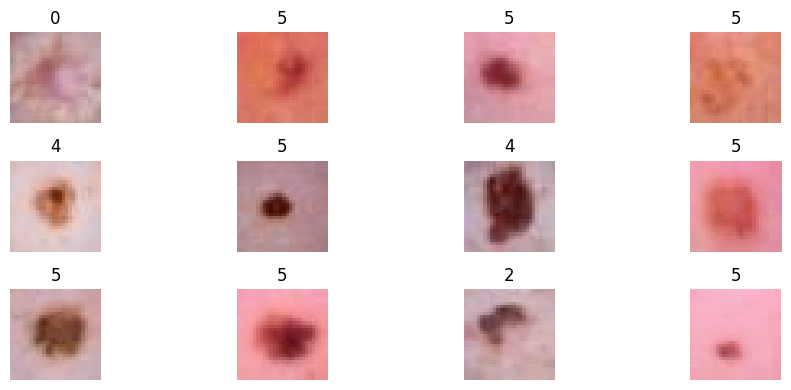

In [4]:
def show_batch(dataset, n=12):
    plt.figure(figsize=(10, 4))
    for i in range(n):
        x, y = dataset[i]
        plt.subplot(3, 4, i+1)
        # CORRECCIÓN: Permute para manejar los 3 canales RGB de DermaMNIST
        img = x.permute(1, 2, 0)
        # CORRECCIÓN: Se elimina cmap="gray" porque la imagen es a color
        plt.imshow(img)
        plt.title(int(y.item()))
        plt.axis("off")
    plt.tight_layout()
    plt.show()

# Ejecuta la función para verificar
show_batch(train_dataset, n=12)

## 4. Preparar DataLoaders y device

Los **DataLoaders** manejan el batching y el shuffle. El **device** nos permite usar GPU si existe.


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

In [6]:
batch_size = 128

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

next(iter(train_loader))[0].shape, next(iter(train_loader))[1].shape


(torch.Size([128, 3, 28, 28]), torch.Size([128, 1]))

## 5. Modelo 1: CNN entrenada desde cero

Construiremos una CNN básica y razonable:
- Bloques conv + ReLU + pooling.
- Al final, un clasificador.

Esta arquitectura no es la única posible: lo valioso es comprender el patrón de diseño.


In [7]:
import torch.nn as nn
import torch.nn.functional as F

num_classes = len(info["label"])

class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            # CORRECCIÓN: in_channels=3 porque DermaMNIST es RGB (3 canales)
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model_scratch = SimpleCNN(num_classes=num_classes).to(device)
model_scratch


SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=64, out_features=7, bias=True)
  )
)

### 5.1. Funciones de entrenamiento y evaluación

En clasificación médica es útil mirar:
- **Accuracy** (porcentaje correcto)
- **ROC-AUC** (capacidad de separar clases)
- **Matriz de confusión**
- **Precision/Recall/F1** (útiles cuando hay desbalance)

Aquí implementaremos un loop de entrenamiento estándar.


In [8]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_labels = []
    all_probs = []
    all_preds = []
    all_losses = []
    criterion_eval = nn.CrossEntropyLoss()

    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long().squeeze(1)

        logits = model(x)
        loss = criterion_eval(logits, y)
        all_losses.append(loss.item())

        # CORRECCIÓN: softmax sobre todas las clases (multiclase)
        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_labels.append(y.cpu().numpy())
        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())

    y_true = np.concatenate(all_labels)
    y_prob = np.concatenate(all_probs)  # shape: (N, num_classes)
    y_pred = np.concatenate(all_preds)
    val_loss = float(np.mean(all_losses))

    acc = accuracy_score(y_true, y_pred)
    # CORRECCIÓN: multi_class='ovr' para problema multiclase con 7 clases
    auc = roc_auc_score(y_true, y_prob, multi_class='ovr', average='macro')
    return acc, auc, y_true, y_pred, y_prob, val_loss

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    losses = []
    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long().squeeze(1)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
    return float(np.mean(losses))


### 5.2. Entrenar el modelo desde cero

Entrenaremos unas pocas épocas para un ejemplo reproducible.
En práctica real, harías búsqueda de hiperparámetros, early stopping y validación más cuidadosa.


In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_scratch.parameters(), lr=1e-3)

epochs = 30
history_scratch = {"train_loss": [], "val_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model_scratch, train_loader, optimizer, criterion)
    val_acc, val_auc, _, _, _, val_loss = evaluate(model_scratch, val_loader)

    history_scratch["train_loss"].append(train_loss)
    history_scratch["val_loss"].append(val_loss)
    history_scratch["val_acc"].append(val_acc)
    history_scratch["val_auc"].append(val_auc)

    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")


Epoch 01 | train_loss=1.3220 | val_loss=1.1263 | val_acc=0.6690 | val_auc=0.5176
Epoch 02 | train_loss=1.0893 | val_loss=1.0541 | val_acc=0.6690 | val_auc=0.6652
Epoch 03 | train_loss=1.0354 | val_loss=1.0277 | val_acc=0.6690 | val_auc=0.6829
Epoch 04 | train_loss=1.0170 | val_loss=1.0143 | val_acc=0.6690 | val_auc=0.7028
Epoch 05 | train_loss=1.0057 | val_loss=1.0144 | val_acc=0.6690 | val_auc=0.7482
Epoch 06 | train_loss=0.9970 | val_loss=0.9884 | val_acc=0.6690 | val_auc=0.7674
Epoch 07 | train_loss=0.9818 | val_loss=0.9835 | val_acc=0.6690 | val_auc=0.8024
Epoch 08 | train_loss=0.9634 | val_loss=0.9444 | val_acc=0.6690 | val_auc=0.8219
Epoch 09 | train_loss=0.9427 | val_loss=0.9319 | val_acc=0.6690 | val_auc=0.8236
Epoch 10 | train_loss=0.9259 | val_loss=0.9074 | val_acc=0.6700 | val_auc=0.8275
Epoch 11 | train_loss=0.9257 | val_loss=0.9049 | val_acc=0.6680 | val_auc=0.8324
Epoch 12 | train_loss=0.9101 | val_loss=0.8997 | val_acc=0.6670 | val_auc=0.8367
Epoch 13 | train_loss=0.8973

### 5.3. Curvas de entrenamiento

Visualizamos pérdida y métricas para detectar sobreajuste.


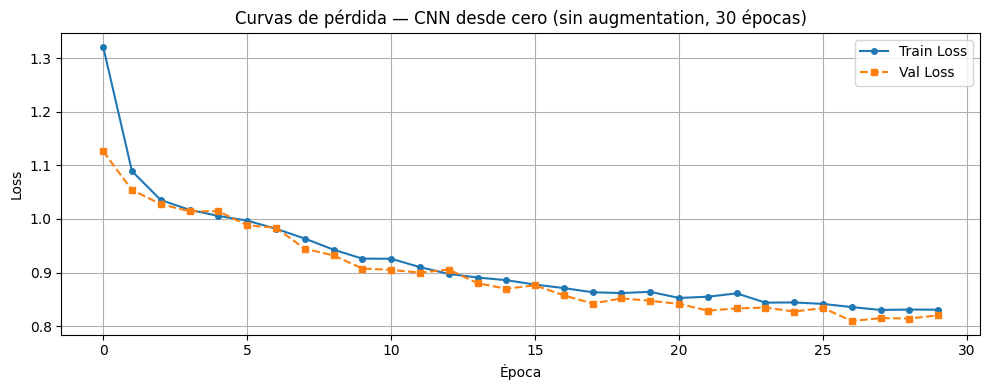

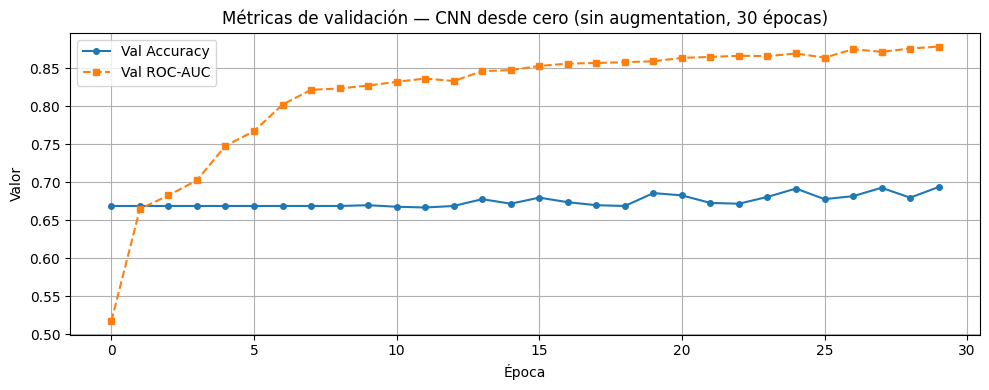

In [10]:
# Curvas de pérdida: CNN sin augmentation
plt.figure(figsize=(10, 4))
plt.plot(history_scratch["train_loss"], label="Train Loss", marker='o', markersize=4)
plt.plot(history_scratch["val_loss"], label="Val Loss", marker='s', markersize=4, linestyle='--')
plt.title("Curvas de pérdida — CNN desde cero (sin augmentation, 30 épocas)")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history_scratch["val_acc"], label="Val Accuracy", marker='o', markersize=4)
plt.plot(history_scratch["val_auc"], label="Val ROC-AUC", marker='s', markersize=4, linestyle='--')
plt.title("Métricas de validación — CNN desde cero (sin augmentation, 30 épocas)")
plt.xlabel("Época")
plt.ylabel("Valor")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### 5.4. Evaluación final en test

La evaluación debe reportarse en un conjunto **no visto** (test) para estimar generalización.


In [11]:
test_acc, test_auc, y_true, y_pred, y_prob, _ = evaluate(model_scratch, test_loader)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test ROC-AUC:  {test_auc:.4f}")
print()
print(classification_report(y_true, y_pred, digits=4))
cm = confusion_matrix(y_true, y_pred)
cm


Test accuracy: 0.6843
Test ROC-AUC:  0.8485

              precision    recall  f1-score   support

           0     0.2162    0.1212    0.1553        66
           1     0.2706    0.4466    0.3370       103
           2     0.4455    0.2227    0.2970       220
           3     0.0000    0.0000    0.0000        23
           4     0.6154    0.0359    0.0678       223
           5     0.7528    0.9403    0.8362      1341
           6     0.0000    0.0000    0.0000        29

    accuracy                         0.6843      2005
   macro avg     0.3286    0.2524    0.2419      2005
weighted avg     0.6419    0.6843    0.6218      2005



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


array([[   8,   25,    3,    0,    0,   30,    0],
       [   3,   46,   10,    0,    0,   44,    0],
       [  11,   29,   49,    0,    0,  131,    0],
       [   2,    7,    0,    0,    0,   14,    0],
       [   6,    6,   25,    0,    8,  178,    0],
       [   7,   48,   20,    0,    5, 1261,    0],
       [   0,    9,    3,    0,    0,   17,    0]])

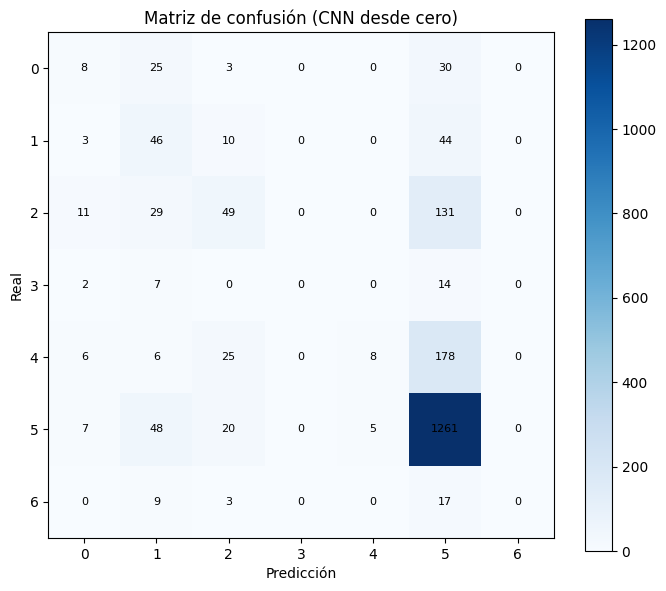

In [12]:
# CORRECCIÓN: matriz de confusión para 7 clases (dinámica)
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap='Blues')
ax.set_title("Matriz de confusión (CNN desde cero)")
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
ticks = list(range(num_classes))
ax.set_xticks(ticks)
ax.set_yticks(ticks)
for i in range(num_classes):
    for j in range(num_classes):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=8)
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


## 6. Data Augmentation (aumento de datos)

En imágenes médicas, el aumento de datos ayuda a generalizar, pero debe aplicarse con cuidado:
- Rotaciones pequeñas y traslaciones suaves suelen ser aceptables.
- Inversiones horizontales/verticales podrían ser inválidas dependiendo del estudio.

Aquí usaremos aumentos moderados. Luego, entrenaremos un modelo con el mismo diseño para comparar.


In [13]:
transform_aug = T.Compose([
    T.RandomRotation(degrees=10),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    T.ToTensor()
])

train_dataset_aug = DataClass(split="train", transform=transform_aug, download=True)
train_loader_aug = DataLoader(train_dataset_aug, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)


In [14]:
model_aug = SimpleCNN(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_aug.parameters(), lr=1e-3)

epochs = 30
history_aug = {"train_loss": [], "val_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model_aug, train_loader_aug, optimizer, criterion)
    val_acc, val_auc, _, _, _, val_loss = evaluate(model_aug, val_loader)

    history_aug["train_loss"].append(train_loss)
    history_aug["val_loss"].append(val_loss)
    history_aug["val_acc"].append(val_acc)
    history_aug["val_auc"].append(val_auc)

    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")


Epoch 01 | train_loss=1.2636 | val_loss=1.1128 | val_acc=0.6690 | val_auc=0.5955
Epoch 02 | train_loss=1.0760 | val_loss=1.0514 | val_acc=0.6690 | val_auc=0.6624
Epoch 03 | train_loss=1.0278 | val_loss=1.0327 | val_acc=0.6690 | val_auc=0.6820
Epoch 04 | train_loss=1.0177 | val_loss=1.0146 | val_acc=0.6690 | val_auc=0.7009
Epoch 05 | train_loss=1.0063 | val_loss=0.9994 | val_acc=0.6690 | val_auc=0.7145
Epoch 06 | train_loss=1.0010 | val_loss=1.0002 | val_acc=0.6690 | val_auc=0.7393
Epoch 07 | train_loss=0.9970 | val_loss=0.9851 | val_acc=0.6690 | val_auc=0.7511
Epoch 08 | train_loss=0.9896 | val_loss=0.9834 | val_acc=0.6690 | val_auc=0.7661
Epoch 09 | train_loss=0.9771 | val_loss=0.9683 | val_acc=0.6690 | val_auc=0.7799
Epoch 10 | train_loss=0.9666 | val_loss=0.9542 | val_acc=0.6690 | val_auc=0.7885
Epoch 11 | train_loss=0.9571 | val_loss=0.9469 | val_acc=0.6690 | val_auc=0.7931
Epoch 12 | train_loss=0.9460 | val_loss=0.9263 | val_acc=0.6690 | val_auc=0.8077
Epoch 13 | train_loss=0.9312

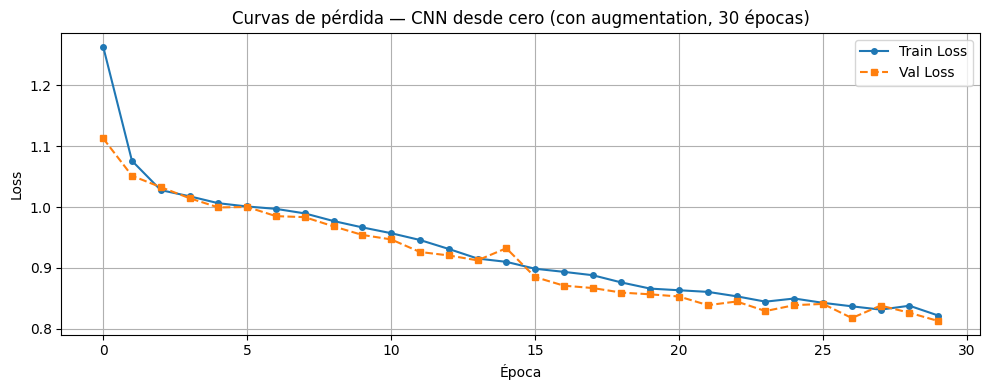

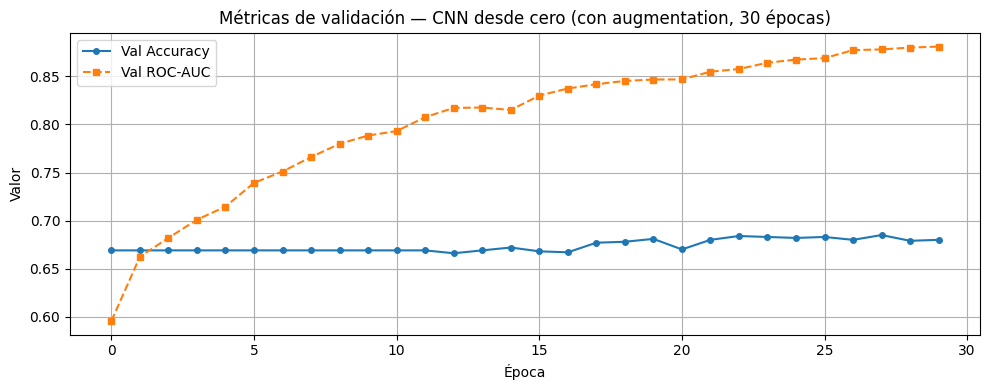

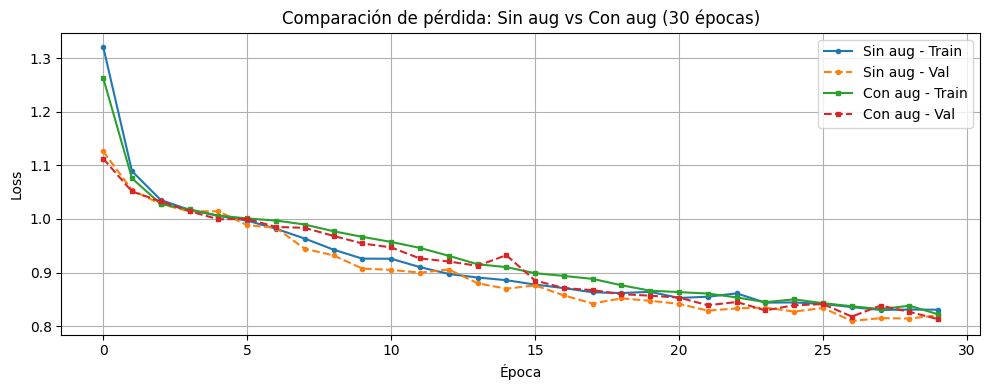

In [15]:
# Curvas de pérdida: CNN con augmentation
plt.figure(figsize=(10, 4))
plt.plot(history_aug["train_loss"], label="Train Loss", marker='o', markersize=4)
plt.plot(history_aug["val_loss"], label="Val Loss", marker='s', markersize=4, linestyle='--')
plt.title("Curvas de pérdida — CNN desde cero (con augmentation, 30 épocas)")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history_aug["val_acc"], label="Val Accuracy", marker='o', markersize=4)
plt.plot(history_aug["val_auc"], label="Val ROC-AUC", marker='s', markersize=4, linestyle='--')
plt.title("Métricas de validación — CNN desde cero (con augmentation, 30 épocas)")
plt.xlabel("Época")
plt.ylabel("Valor")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Comparación directa: train_loss sin aug vs con aug
plt.figure(figsize=(10, 4))
plt.plot(history_scratch["train_loss"], label="Sin aug - Train", marker='o', markersize=3)
plt.plot(history_scratch["val_loss"], label="Sin aug - Val", marker='o', markersize=3, linestyle='--')
plt.plot(history_aug["train_loss"], label="Con aug - Train", marker='s', markersize=3)
plt.plot(history_aug["val_loss"], label="Con aug - Val", marker='s', markersize=3, linestyle='--')
plt.title("Comparación de pérdida: Sin aug vs Con aug (30 épocas)")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### 6.1. Comparación rápida


In [16]:
test_acc_aug, test_auc_aug, _, _, _, _ = evaluate(model_aug, test_loader)
print(f"Sin augmentation  | test_acc={test_acc:.4f} | test_auc={test_auc:.4f}")
print(f"Con augmentation  | test_acc={test_acc_aug:.4f} | test_auc={test_auc_aug:.4f}")


Sin augmentation  | test_acc=0.6843 | test_auc=0.8485
Con augmentation  | test_acc=0.6838 | test_auc=0.8585


## 7. Transfer Learning en imágenes médicas

El **transfer learning** consiste en reutilizar un modelo entrenado en un dataset grande (por ejemplo, ImageNet) y adaptarlo a tu tarea.

Ventajas:
- Converge más rápido.
- Suele mejorar rendimiento con pocos datos.

Desafíos en imágenes médicas:
- Muchas imágenes médicas son en escala de grises.
- El dominio es distinto a fotos naturales.

Aun así, usar redes como ResNet puede ayudar. Aquí haremos:
1) Convertir la imagen a 3 canales.
2) Redimensionar a un tamaño típico de ResNet.
3) Entrenar un clasificador encima.


In [17]:
import torchvision.models as models

transform_tl_train = T.Compose([
    T.Resize((224, 224)),
    T.RandomRotation(degrees=10),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    T.ToTensor(),
    # CORRECCIÓN: se eliminó T.Lambda(repeat) porque DermaMNIST ya tiene 3 canales RGB
])

transform_tl_eval = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    # CORRECCIÓN: se eliminó T.Lambda(repeat) porque DermaMNIST ya tiene 3 canales RGB
])

train_dataset_tl = DataClass(split="train", transform=transform_tl_train, download=True)
val_dataset_tl = DataClass(split="val", transform=transform_tl_eval, download=True)
test_dataset_tl = DataClass(split="test", transform=transform_tl_eval, download=True)

train_loader_tl = DataLoader(train_dataset_tl, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
val_loader_tl = DataLoader(val_dataset_tl, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
test_loader_tl = DataLoader(test_dataset_tl, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

next(iter(train_loader_tl))[0].shape


torch.Size([64, 3, 224, 224])

### 7.1. Construir el modelo preentrenado

Usaremos **ResNet18** preentrenada en ImageNet.

Estrategia:
- Congelar el backbone al inicio.
- Entrenar solo la última capa.
- Luego, opcionalmente, descongelar algunas capas para fine-tuning.


In [18]:
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
in_features = resnet.fc.in_features
resnet.fc = nn.Linear(in_features, num_classes)
resnet = resnet.to(device)

for name, param in resnet.named_parameters():
    param.requires_grad = False

for param in resnet.fc.parameters():
    param.requires_grad = True

resnet


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 182MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [19]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(resnet.fc.parameters(), lr=1e-3)

epochs = 4
history_tl_stage1 = {"train_loss": [], "val_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(resnet, train_loader_tl, optimizer, criterion)
    val_acc, val_auc, _, _, _, val_loss = evaluate(resnet, val_loader_tl)

    history_tl_stage1["train_loss"].append(train_loss)
    history_tl_stage1["val_loss"].append(val_loss)
    history_tl_stage1["val_acc"].append(val_acc)
    history_tl_stage1["val_auc"].append(val_auc)

    print(f"Stage1 Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")


Stage1 Epoch 01 | train_loss=0.9849 | val_loss=0.8422 | val_acc=0.7019 | val_auc=0.8574
Stage1 Epoch 02 | train_loss=0.8523 | val_loss=0.8069 | val_acc=0.7059 | val_auc=0.9002
Stage1 Epoch 03 | train_loss=0.8079 | val_loss=0.7386 | val_acc=0.7368 | val_auc=0.9107
Stage1 Epoch 04 | train_loss=0.7821 | val_loss=0.7333 | val_acc=0.7358 | val_auc=0.9156


### 7.2. Fine-tuning (descongelar capas)

Ahora permitiremos que el modelo ajuste parte del backbone.
Una práctica común es descongelar las últimas capas del extractor de características.


In [20]:
for name, param in resnet.named_parameters():
    if name.startswith("layer4") or name.startswith("fc"):
        param.requires_grad = True

trainable_params = [p for p in resnet.parameters() if p.requires_grad]
len(trainable_params)


17

In [21]:
optimizer = torch.optim.Adam(trainable_params, lr=1e-4)

epochs = 4
history_tl_stage2 = {"train_loss": [], "val_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(resnet, train_loader_tl, optimizer, criterion)
    val_acc, val_auc, _, _, _, val_loss = evaluate(resnet, val_loader_tl)

    history_tl_stage2["train_loss"].append(train_loss)
    history_tl_stage2["val_loss"].append(val_loss)
    history_tl_stage2["val_acc"].append(val_acc)
    history_tl_stage2["val_auc"].append(val_auc)

    print(f"Stage2 Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")


Stage2 Epoch 01 | train_loss=0.7104 | val_loss=0.6843 | val_acc=0.7527 | val_auc=0.9293
Stage2 Epoch 02 | train_loss=0.5790 | val_loss=0.6499 | val_acc=0.7627 | val_auc=0.9367
Stage2 Epoch 03 | train_loss=0.5071 | val_loss=0.6705 | val_acc=0.7498 | val_auc=0.9325
Stage2 Epoch 04 | train_loss=0.4283 | val_loss=0.6910 | val_acc=0.7767 | val_auc=0.9356


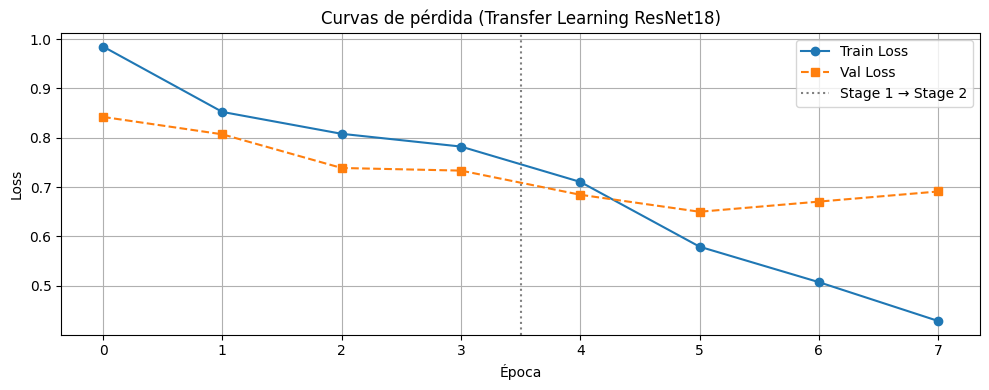

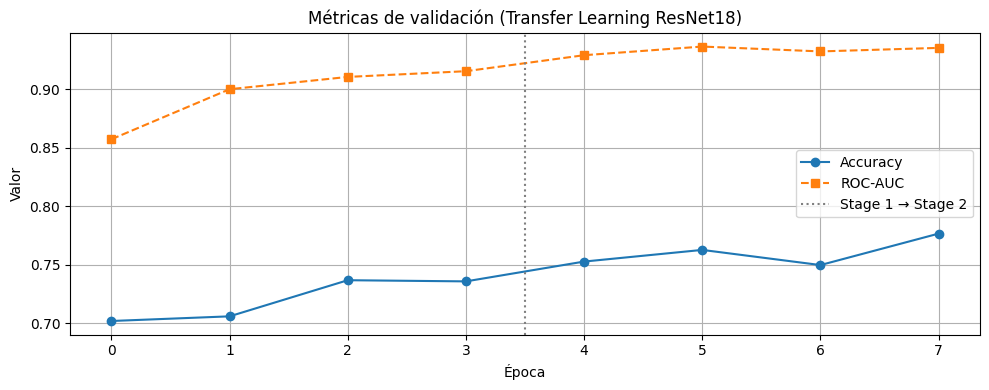

In [22]:
# Curvas de pérdida: Transfer Learning (Stage 1 + Stage 2 combinados)
history_tl_combined = {
    "train_loss": history_tl_stage1["train_loss"] + history_tl_stage2["train_loss"],
    "val_loss":   history_tl_stage1["val_loss"]   + history_tl_stage2["val_loss"],
    "val_acc":    history_tl_stage1["val_acc"]    + history_tl_stage2["val_acc"],
    "val_auc":    history_tl_stage1["val_auc"]    + history_tl_stage2["val_auc"],
}

plt.figure(figsize=(10, 4))
plt.plot(history_tl_combined["train_loss"], label="Train Loss", marker='o')
plt.plot(history_tl_combined["val_loss"], label="Val Loss", marker='s', linestyle='--')
plt.axvline(x=3.5, color='gray', linestyle=':', label='Stage 1 → Stage 2')
plt.title("Curvas de pérdida (Transfer Learning ResNet18)")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history_tl_combined["val_acc"], label="Accuracy", marker='o')
plt.plot(history_tl_combined["val_auc"], label="ROC-AUC", marker='s', linestyle='--')
plt.axvline(x=3.5, color='gray', linestyle=':', label='Stage 1 → Stage 2')
plt.title("Métricas de validación (Transfer Learning ResNet18)")
plt.xlabel("Época")
plt.ylabel("Valor")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### 7.3. Evaluación en test del modelo con transfer learning


In [23]:
test_acc_tl, test_auc_tl, y_true_tl, y_pred_tl, y_prob_tl, _ = evaluate(resnet, test_loader_tl)
print(f"Transfer learning | test_acc={test_acc_tl:.4f} | test_auc={test_auc_tl:.4f}")
print()
print(classification_report(y_true_tl, y_pred_tl, digits=4))
cm_tl = confusion_matrix(y_true_tl, y_pred_tl)
cm_tl


Transfer learning | test_acc=0.7641 | test_auc=0.9214

              precision    recall  f1-score   support

           0     0.5106    0.3636    0.4248        66
           1     0.5312    0.4951    0.5126       103
           2     0.5543    0.4409    0.4911       220
           3     0.6250    0.4348    0.5128        23
           4     0.4727    0.4664    0.4695       223
           5     0.8624    0.9157    0.8882      1341
           6     0.6667    0.6207    0.6429        29

    accuracy                         0.7641      2005
   macro avg     0.6033    0.5339    0.5631      2005
weighted avg     0.7511    0.7641    0.7557      2005



array([[  24,   17,    4,    1,   13,    6,    1],
       [   8,   51,    9,    3,    6,   23,    3],
       [   5,   12,   97,    1,   39,   66,    0],
       [   2,    3,    2,   10,    1,    5,    0],
       [   4,    1,   21,    1,  104,   89,    3],
       [   4,   10,   42,    0,   55, 1228,    2],
       [   0,    2,    0,    0,    2,    7,   18]])

### 7.4. Comparación global (resumen)


In [24]:
print("Resumen de resultados en test")
print(f"CNN desde cero (sin aug)  | acc={test_acc:.4f} | auc={test_auc:.4f}")
print(f"CNN desde cero (con aug)  | acc={test_acc_aug:.4f} | auc={test_auc_aug:.4f}")
print(f"Transfer learning (ResNet) | acc={test_acc_tl:.4f} | auc={test_auc_tl:.4f}")


Resumen de resultados en test
CNN desde cero (sin aug)  | acc=0.6843 | auc=0.8485
CNN desde cero (con aug)  | acc=0.6838 | auc=0.8585
Transfer learning (ResNet) | acc=0.7641 | auc=0.9214


## 8. Interpretabilidad básica: Grad-CAM

En salud, entender por qué el modelo decide es importante.

**Grad-CAM** produce un mapa de calor sobre la imagen, indicando regiones que más influyeron en la predicción.

Aquí implementaremos una versión simplificada para ResNet18.


In [25]:
import torch

def grad_cam(model, image_tensor, target_class=None):
    model.eval()
    image_tensor = image_tensor.to(device)

    activations = {}
    gradients = {}

    def forward_hook(module, inp, out):
        activations["value"] = out

    def backward_hook(module, grad_in, grad_out):
        gradients["value"] = grad_out[0]

    handle_fwd = model.layer4.register_forward_hook(forward_hook)
    handle_bwd = model.layer4.register_full_backward_hook(backward_hook)

    logits = model(image_tensor.unsqueeze(0))
    if target_class is None:
        target_class = int(torch.argmax(logits, dim=1).item())

    score = logits[0, target_class]
    model.zero_grad()
    score.backward()

    act = activations["value"][0]
    grad = gradients["value"][0]

    weights = torch.mean(grad, dim=(1, 2))
    cam = torch.sum(weights[:, None, None] * act, dim=0)

    cam = torch.relu(cam)
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)

    handle_fwd.remove()
    handle_bwd.remove()

    return cam.detach().cpu().numpy(), target_class


sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


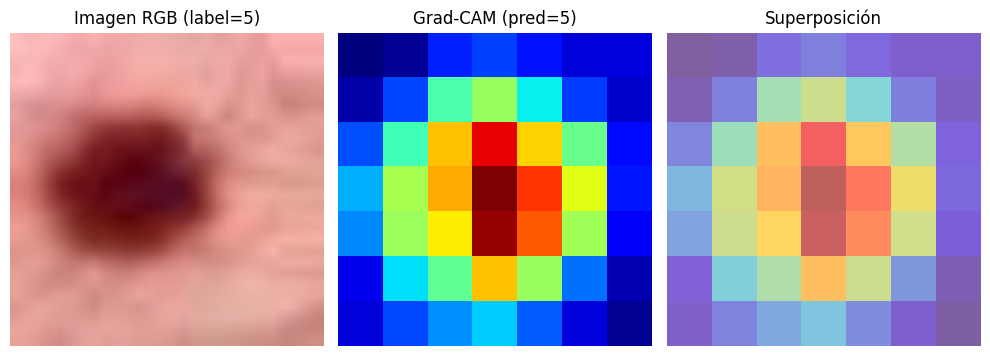

In [26]:
idx = 0
x, y = test_dataset_tl[idx]
cam, pred_class = grad_cam(resnet, x)

# CORRECCIÓN: mostrar imagen RGB (permutar de CHW a HWC) en lugar de solo el canal R
img_rgb = x.permute(1, 2, 0).numpy()
img_rgb = (img_rgb - img_rgb.min()) / (img_rgb.max() - img_rgb.min() + 1e-8)  # normalizar a [0,1]

plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title(f"Imagen RGB (label={int(y.item())})")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cam, cmap='jet')
plt.title(f"Grad-CAM (pred={pred_class})")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img_rgb)
plt.imshow(cam, alpha=0.5, cmap='jet')
plt.title("Superposición")
plt.axis("off")

plt.tight_layout()
plt.show()


## 9. Buenas prácticas (especialmente en salud)

1) **Separación estricta** de train/val/test para evitar data leakage.

2) Reportar métricas más allá de accuracy:
- **Recall (sensibilidad)**: qué tanto detectas positivos.
- **Especificidad**: qué tanto evitas falsos positivos.
- **ROC-AUC**: separación global.

3) Cuidado con sesgos:
- Diferencias por equipo, hospital, población.
- Etiquetas ruidosas.

4) Validación externa:
- Probar en datos de otra fuente es clave.

5) Interpretabilidad:
- Grad-CAM es útil, pero no prueba causalidad.

6) Reproducibilidad:
- Fijar seeds, registrar versiones, guardar modelos.


## 10. Guardar y cargar modelos

Guardar el modelo permite reutilizarlo y desplegarlo en aplicaciones.


In [27]:
import os

os.makedirs("models", exist_ok=True)

torch.save(model_scratch.state_dict(), "models/cnn_scratch.pth")
torch.save(model_aug.state_dict(), "models/cnn_aug.pth")
torch.save(resnet.state_dict(), "models/resnet_transfer.pth")

["models/cnn_scratch.pth", "models/cnn_aug.pth", "models/resnet_transfer.pth"]


['models/cnn_scratch.pth', 'models/cnn_aug.pth', 'models/resnet_transfer.pth']

## 11. Ejercicios sugeridos

1) Cambia la arquitectura de la CNN: agrega BatchNorm, Dropout, o más filtros.

2) Experimenta con learning rate y scheduler.

3) Analiza el impacto de diferentes aumentos de datos.

4) Cambia el dataset dentro de `medmnist` (por ejemplo: `breastmnist`, `dermamnist`) y adapta el pipeline.

5) Implementa calibración de probabilidades y analiza curvas ROC.


---
## 12. Explicación del modelo e interpretabilidad

Esta sección resume los principios fundamentales que explican **por qué este modelo funciona**, cómo interpretar sus decisiones y qué limitaciones debemos tener en cuenta.


### 12.1. ¿Qué aprendió la CNN?

Una CNN aprende representaciones **jerárquicas** de la imagen durante el entrenamiento:

| Capa | Lo que aprende |
|------|----------------|
| Conv1 (superficial) | Bordes, gradientes de intensidad, cambios bruscos de color |
| Conv2 (intermedia) | Texturas, manchas, estructuras locales |
| Conv3 (profunda) | Formas complejas, regiones semánticamente relevantes |
| Fully-connected | Combinación ponderada de todas las características para clasificar |

En el contexto de DermaMNIST (imágenes dermatológicas), las capas profundas aprenden a reconocer patrones visuales asociados a cada tipo de lesión cutánea.


### 12.2. Interpretabilidad con Grad-CAM

**Grad-CAM (Gradient-weighted Class Activation Mapping)** es la técnica de interpretabilidad implementada en la Sección 8. Permite entender *dónde* miró el modelo para tomar su decisión.

**¿Cómo funciona?**

1. Se registra la activación del mapa de características en la última capa convolucional ( en ResNet18).
2. Se calcula el gradiente de la clase predicha respecto a esas activaciones mediante backpropagation.
3. Los gradientes se promedian por canal (ponderación): canales con mayor gradiente aportan más a la decisión.
4. Se combina la ponderación con los mapas de activación para obtener un mapa de calor 2D.
5. El mapa se normaliza entre 0 y 1 y se superpone sobre la imagen original.

**Interpretación visual:**

- Zonas en **rojo/amarillo** (valores altos): regiones que más influyeron en la predicción.
- Zonas en **azul** (valores bajos): regiones ignoradas por el modelo.




### 12.3. Diferencias entre los tres modelos entrenados

| Característica | CNN desde cero (sin aug) | CNN desde cero (con aug) | Transfer Learning (ResNet18) |
|----------------|--------------------------|--------------------------|------------------------------|
| Parámetros totales | ~50K | ~50K | ~11M |
| Conocimiento previo | Ninguno | Ninguno | ImageNet (1.2M imágenes) |
| Épocas entrenadas | 30 | 30 | 8 (4+4) |
| Riesgo de sobreajuste | Medio | Reducido (aug) | Bajo (backbone congelado) |
| Velocidad de convergencia | Lenta | Lenta | Rápida |
| Interpretabilidad Grad-CAM | Posible en última conv | Posible en última conv | Implementada en  |

> **Conclusión práctica:** En datasets médicos pequeños, el transfer learning generalmente supera a los modelos entrenados desde cero, tanto en rendimiento como en velocidad de entrenamiento.


### 12.4. Limitaciones de interpretabilidad

Es fundamental entender qué **no** nos dice Grad-CAM:

**1. No implica causalidad.**  
El modelo puede activarse en una región clínicamente relevante por correlación estadística, no porque haya aprendido el mecanismo biológico subyacente.

**2. Resolución limitada.**  
Grad-CAM produce mapas de baja resolución (dependientes del tamaño del mapa de características), que luego son redimensionados. Hay variantes más precisas como *Grad-CAM++* o *Score-CAM*.

**3. Sensible a la clase objetivo.**  
El mismo modelo produce mapas diferentes para distintas clases objetivo. Siempre especificar qué clase se está analizando.

**4. No valida el modelo clínicamente.**  
Un mapa de calor visualmente razonable no reemplaza la validación clínica, la revisión por expertos ni los estudios de sesgo.


### 12.5. Otras técnicas de interpretabilidad (para explorar)

Grad-CAM es solo una de varias herramientas disponibles:

| Técnica | Descripción breve | Ventaja principal |
|---------|-------------------|-------------------|
| **LIME** | Aproxima localmente el modelo con uno interpretable | Agnóstica al modelo |
| **SHAP** | Valores de Shapley para atribución de características | Base teórica sólida |
| **Grad-CAM++** | Mejora de Grad-CAM con ponderación mejorada | Mayor precisión espacial |
| **Score-CAM** | Usa perturbaciones en lugar de gradientes | Sin ruido de gradientes |
| **Attention maps** | Mecanismos de atención en Vision Transformers | Nativa en arquitecturas ViT |




### 12.6. Checklist de responsabilidad (modelos en salud)

Antes de llevar cualquier modelo a un contexto clínico real, se debe verificar:

- [ ] ✅ **Separación estricta train/val/test** — sin data leakage en ninguna etapa.
- [ ] ✅ **Métricas completas reportadas** — accuracy + AUC + recall + especificidad.
- [ ] ✅ **Análisis de distribución de errores** — ¿en qué clases falla más? ¿hay sesgo sistemático?
- [ ] ✅ **Validación externa** — probado en datos de otra institución o población.
- [ ] ✅ **Interpretabilidad auditada** — los mapas de calor apuntan a regiones clínicamente coherentes.
- [ ] ✅ **Documentación de sesgos** — declarar posibles sesgos de equipo, demografía o etiquetado.
- [ ] ✅ **Revisión por expertos clínicos** — ningún modelo médico debe desplegarse sin validación humana.

---

> ⚠️ **Recordatorio final:** Este notebook tiene propósitos educativos. Los modelos aquí entrenados demuestran principios técnicos pero **no están listos para uso diagnóstico**. La inteligencia artificial en salud requiere rigor regulatorio, datos representativos y validación clínica independiente.
